In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/job-market-analytics/data/jobs_in_data_2024.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (14199, 12)

Columns: ['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'work_setting', 'company_location', 'company_size', 'job_category']

First 5 rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,work_setting,company_location,company_size,job_category
0,2024,Entry-level,Freelance,Applied Data Scientist,30000,USD,30000,United Kingdom,Remote,United Kingdom,M,Data Science and Research
1,2024,Executive,Full-time,Business Intelligence,230000,USD,230000,United States,In-person,United States,M,BI and Visualization
2,2024,Executive,Full-time,Business Intelligence,176900,USD,176900,United States,In-person,United States,M,BI and Visualization
3,2024,Senior,Full-time,Data Architect,171210,USD,171210,Canada,In-person,Canada,M,Data Architecture and Modeling
4,2024,Senior,Full-time,Data Architect,92190,USD,92190,Canada,In-person,Canada,M,Data Architecture and Modeling


In [ ]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nExperience Levels:", df['experience_level'].unique())
print("Work Settings:", df['work_setting'].unique())
print("Company Sizes:", df['company_size'].unique())
print("Years:", df['work_year'].unique())

Shape: (14199, 12)

Data Types:
 work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
work_setting          object
company_location      object
company_size          object
job_category          object
dtype: object

Missing Values:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
work_setting          0
company_location      0
company_size          0
job_category          0
dtype: int64

Experience Levels: ['Entry-level' 'Executive' 'Senior' 'Mid-level']
Work Settings: ['Remote' 'In-person' 'Hybrid']
Company Sizes: ['M' 'S' 'L']
Years: [2024 2023 2022 2020 2021]


/tmp/ipykernel_562/2253726494.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_jobs, x='salary_in_usd', y='job_title', palette='Blues_r')


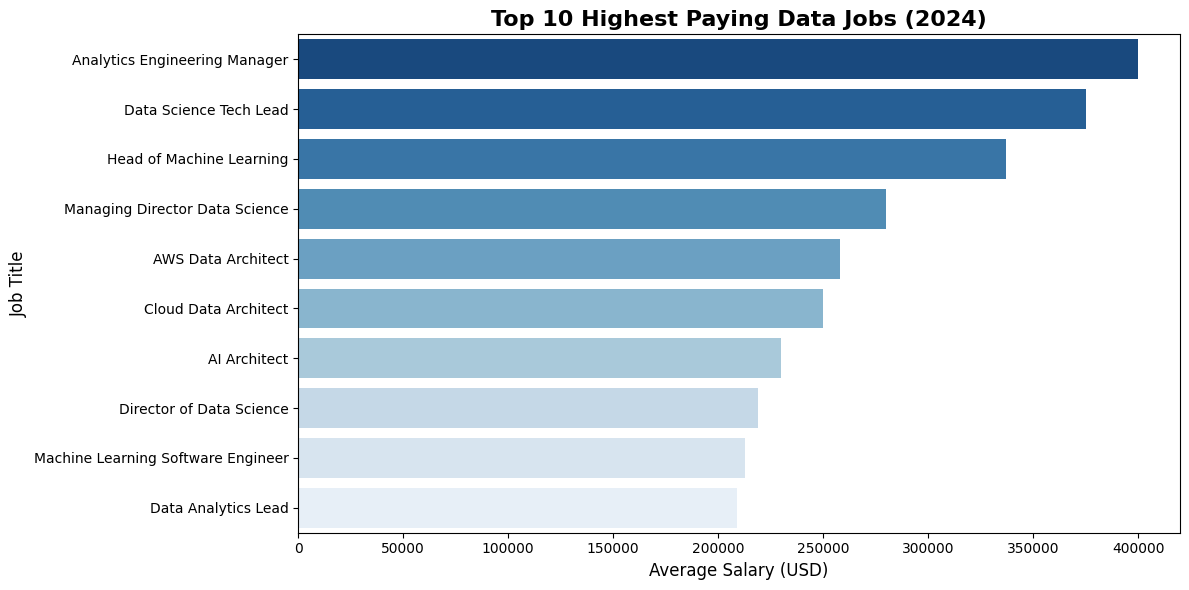

Chart 1 saved!


In [ ]:
plt.figure(figsize=(12, 6))

top_jobs = (df.groupby('job_title')['salary_in_usd']
              .mean()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

sns.barplot(data=top_jobs, x='salary_in_usd', y='job_title', palette='Blues_r')

plt.title('Top 10 Highest Paying Data Jobs (2024)', fontsize=16, fontweight='bold')
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/job-market-analytics/chart1_top_paying_jobs.png', dpi=150)
plt.show()
print("Chart 1 saved!")

/tmp/ipykernel_562/946913346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary_in_usd',


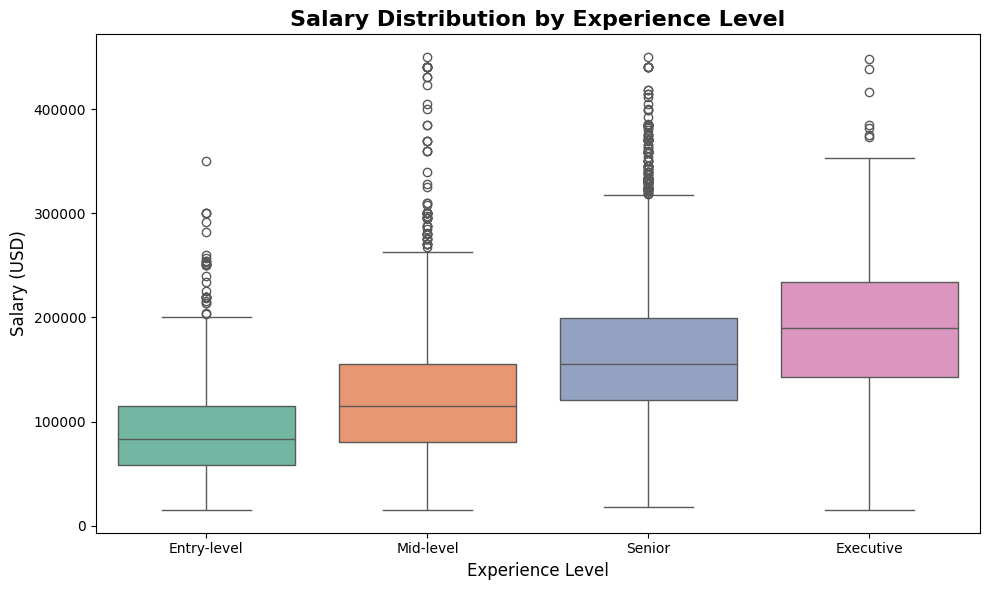

Chart 2 saved!


In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='experience_level', y='salary_in_usd',
            palette='Set2',
            order=['Entry-level', 'Mid-level', 'Senior', 'Executive'])

plt.title('Salary Distribution by Experience Level', fontsize=16, fontweight='bold')
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/job-market-analytics/chart2_salary_by_experience.png', dpi=150)
plt.show()
print("Chart 2 saved!")

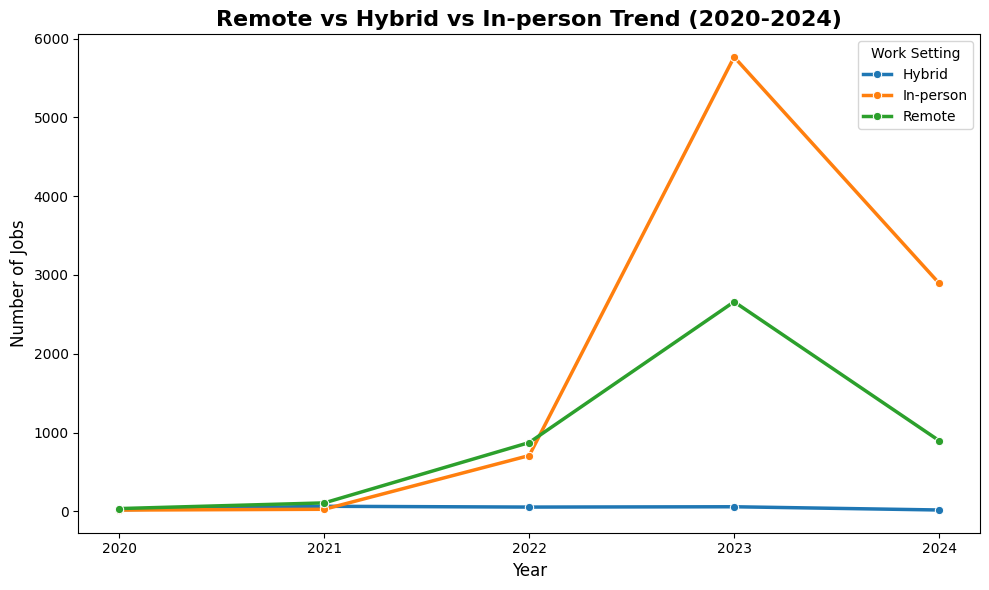

Chart 3 saved!


In [ ]:
plt.figure(figsize=(10, 6))

remote_trend = (df.groupby(['work_year', 'work_setting'])
                  .size()
                  .reset_index(name='count'))

sns.lineplot(data=remote_trend, x='work_year', y='count',
             hue='work_setting', marker='o', linewidth=2.5)

plt.title('Remote vs Hybrid vs In-person Trend (2020-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.legend(title='Work Setting')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/job-market-analytics/chart3_remote_trend.png', dpi=150)
plt.show()
print("Chart 3 saved!")

/tmp/ipykernel_562/1139908341.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='count', y='country', palette='Oranges_r')


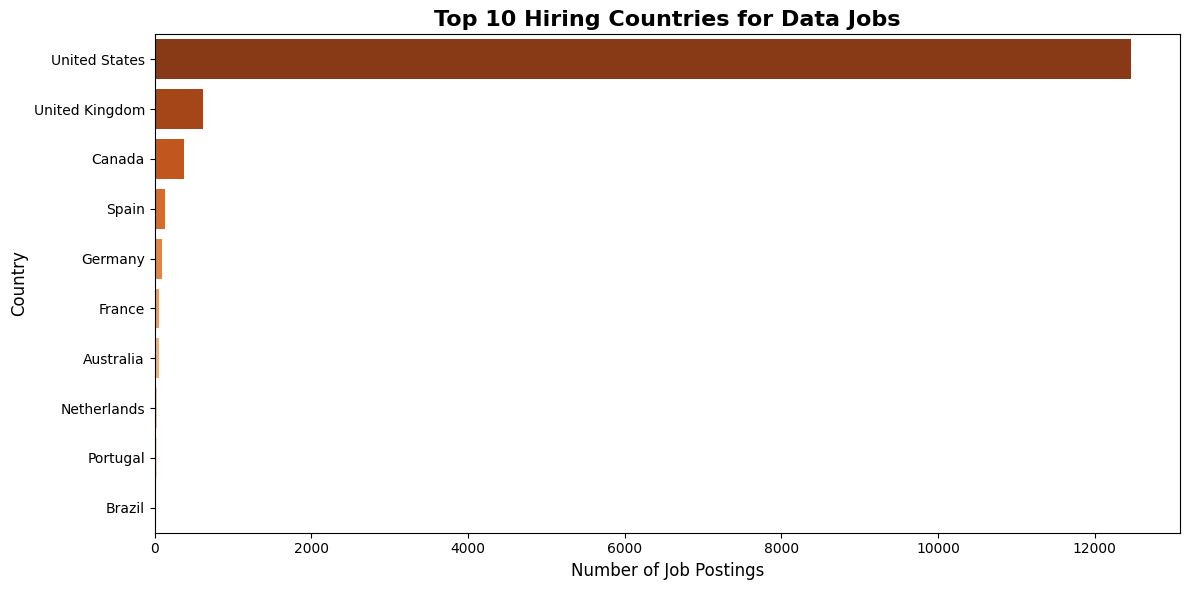

Chart 4 saved!


In [ ]:
plt.figure(figsize=(12, 6))

top_countries = (df['company_location']
                   .value_counts()
                   .head(10)
                   .reset_index())
top_countries.columns = ['country', 'count']

sns.barplot(data=top_countries, x='count', y='country', palette='Oranges_r')

plt.title('Top 10 Hiring Countries for Data Jobs', fontsize=16, fontweight='bold')
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/job-market-analytics/chart4_top_countries.png', dpi=150)
plt.show()
print("Chart 4 saved!")

/tmp/ipykernel_562/1098483728.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_salary, x='company_size', y='salary_in_usd',


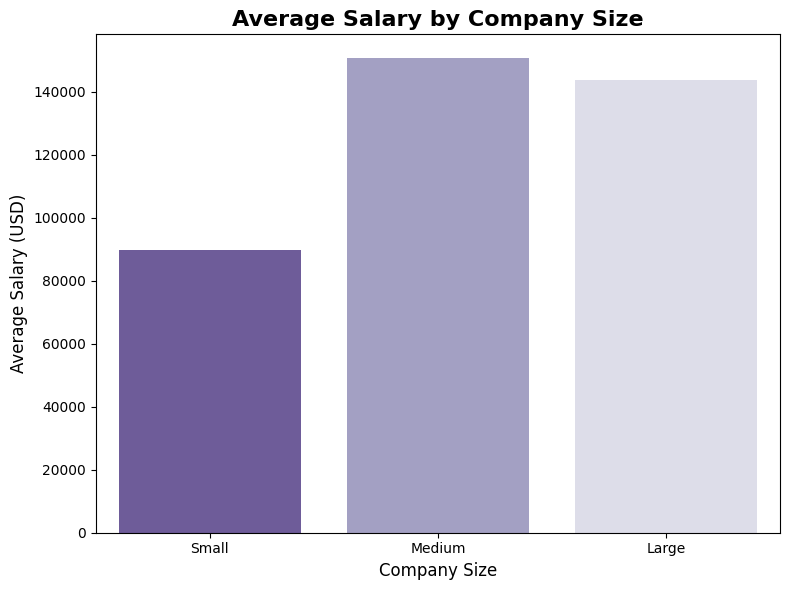

Chart 5 saved!


In [ ]:
plt.figure(figsize=(8, 6))

size_salary = (df.groupby('company_size')['salary_in_usd']
                 .mean()
                 .reset_index())
size_salary['company_size'] = size_salary['company_size'].map({'S': 'Small', 'M': 'Medium', 'L': 'Large'})

sns.barplot(data=size_salary, x='company_size', y='salary_in_usd',
            palette='Purples_r',
            order=['Small', 'Medium', 'Large'])

plt.title('Average Salary by Company Size', fontsize=16, fontweight='bold')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/job-market-analytics/chart5_company_size_salary.png', dpi=150)
plt.show()
print("Chart 5 saved!")

In [ ]:
# Save cleaned dataframe as Excel for Power BI and Excel phase
df.to_excel('/content/drive/MyDrive/job-market-analytics/data/ds_jobs_2024_cleaned.xlsx', index=False)
print("Cleaned Excel file saved!")

# Quick summary stats
print("\n--- Dataset Summary ---")
print(f"Total Jobs: {len(df):,}")
print(f"Average Salary: ${df['salary_in_usd'].mean():,.0f}")
print(f"Top Hiring Country: {df['company_location'].value_counts().index[0]}")
print(f"% Remote Jobs: {(df['work_setting']=='Remote').mean()*100:.1f}%")
print(f"Unique Job Titles: {df['job_title'].nunique()}")
print(f"Unique Countries: {df['company_location'].nunique()}")

Cleaned Excel file saved!

--- Dataset Summary ---
Total Jobs: 14,199
Average Salary: $149,472
Top Hiring Country: United States
% Remote Jobs: 32.2%
Unique Job Titles: 149
Unique Countries: 74
